<a href="https://colab.research.google.com/github/Kado2/EDA_videogames_sales_-_industry_data-1980_2024-/blob/main/Version_en_esp/03_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
<center><img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExejZwY3lqcGpleWh4ZnBtOTU4amQ5bTdnamZ3eGxpMDMwNmI4ZWp2ayZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/H7AsEcCf7K0fCqlB77/giphy.gif"></center>

---

# Introducción

En esta parte del análisis, se responderan a las siguientes preguntas relacionadas a las ventas:

1.  ¿Qué año tuvo las mayores ventas a nivel mundial?

2.  ¿Qué género ha vendido más en un solo año?

3.  ¿Cuáles son los 5 géneros con más ventas en todo el mundo?

4.  ¿Qué plataforma acumula más ventas a nivel mundial?

5.  Top 10 juegos más vendidos en todo el mundo

6.  Comparación de ventas por género y región.

7.  Top 5 géneros más vendidos por plataforma.

8.  Ventas globales y por área según editor.

9.  Ventas totales por región.


Es importante aclarar la falta proporción de datos nulos en total_sales respecto al dataset original: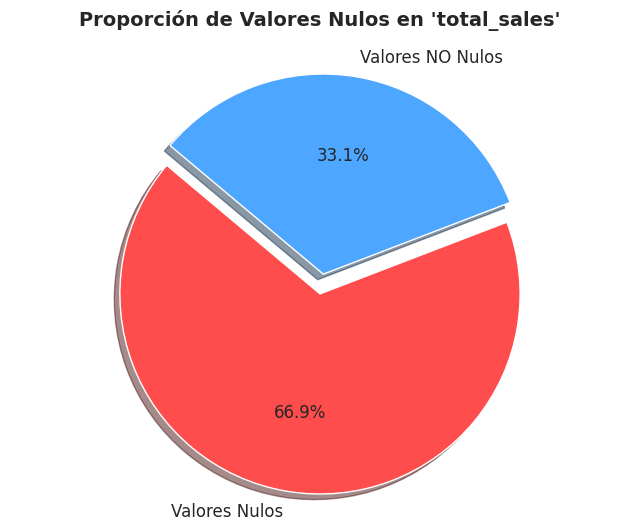

In [19]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)


import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_style('whitegrid')

In [20]:
import gdown

# Enlace al .csv
url = 'https://drive.google.com/file/d/1Q0GDFmKKl4F20iqUt9U3fwCvz8SeOtG7/view?usp=drive_link'

# Nombra este archivo como sales_analysis_cleaned_esp.csv
output = "sales_analysis_cleaned_esp.csv"

# Se realiza la descarga usando gdown
file_path = gdown.download(url, output, fuzzy=True)

df = pd.read_csv(file_path, sep=",")

Downloading...
From: https://drive.google.com/uc?id=1Q0GDFmKKl4F20iqUt9U3fwCvz8SeOtG7
To: /content/sales_analysis_cleaned_esp.csv
100%|██████████| 1.65M/1.65M [00:00<00:00, 37.0MB/s]


In [21]:
df.head(5)

,title,console,genre,publisher,developer,total_sales,na_sales,jp_sales,pal_sales,other_sales,year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,20.32,6.37,0.99,9.85,3.12,2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,19.39,6.06,0.60,9.71,3.02,2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,16.15,8.41,0.47,5.49,1.78,2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,15.86,9.06,0.06,5.33,1.42,2013
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,15.09,6.18,0.41,6.05,2.44,2015


# Relación general entre las variables

<Axes: >

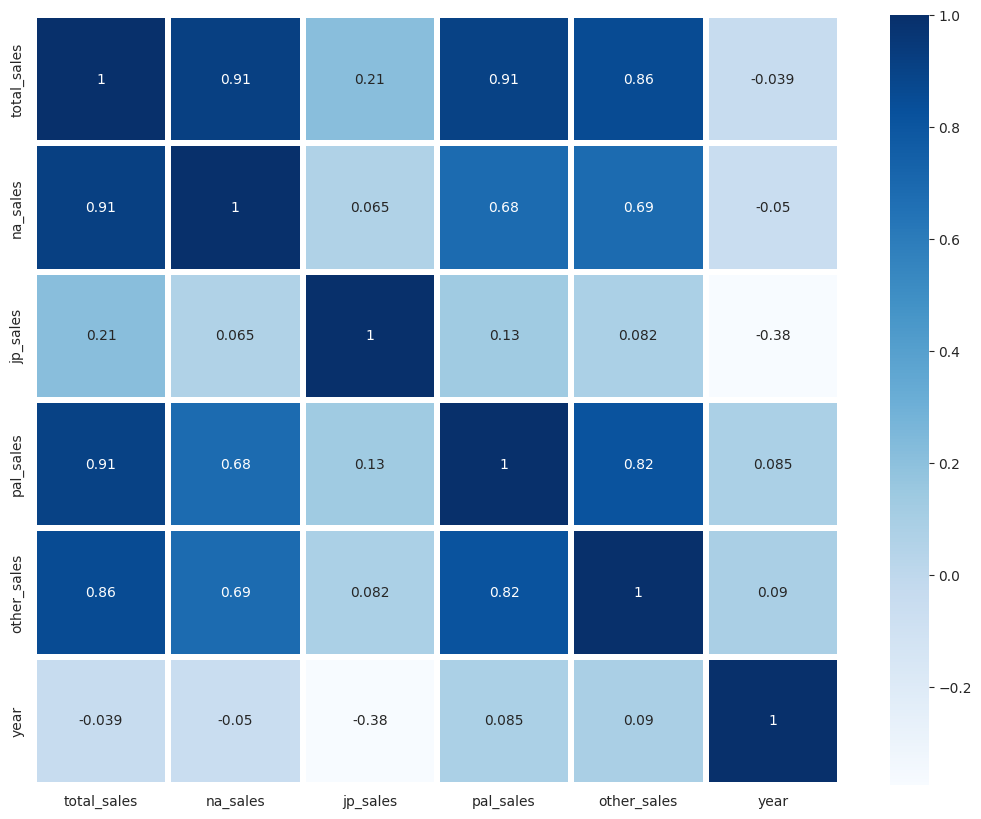

In [22]:
plt.figure(figsize=(13,10))
sns.heatmap(df.drop(columns=['title', 'console', 'genre', 'publisher', 'developer']).corr(), cmap = "Blues", annot=True, linewidth=3)

Norteamérica y Europa presentan una correlación fuerte entre sí (0.68), lo que sugiere que ambas regiones comparten tendencias de consumo, es muy probable que un juego exitoso en cualquiera de las dos regiones sea exitoso a nivel global. El mercado japonés según el heatmap es un público objetivo más de nicho, para investigar cómo lanzar un juego aceptado en esa región, es necesario hacer un analisis más enfocado en dicho mercado.

Por otro lado, la variable del año de lanzamiento muestra una correlación casi nula con el volumen de ventas. Un juego puede alcanzar cifras de ventas masivas independientemente de si fue lanzado en 1995 o en 2020.

In [23]:
# Acorta el dataset para que tarde menos
data_pair = df.loc[:,["year", "genre", "na_sales", "pal_sales", "other_sales","jp_sales"]]

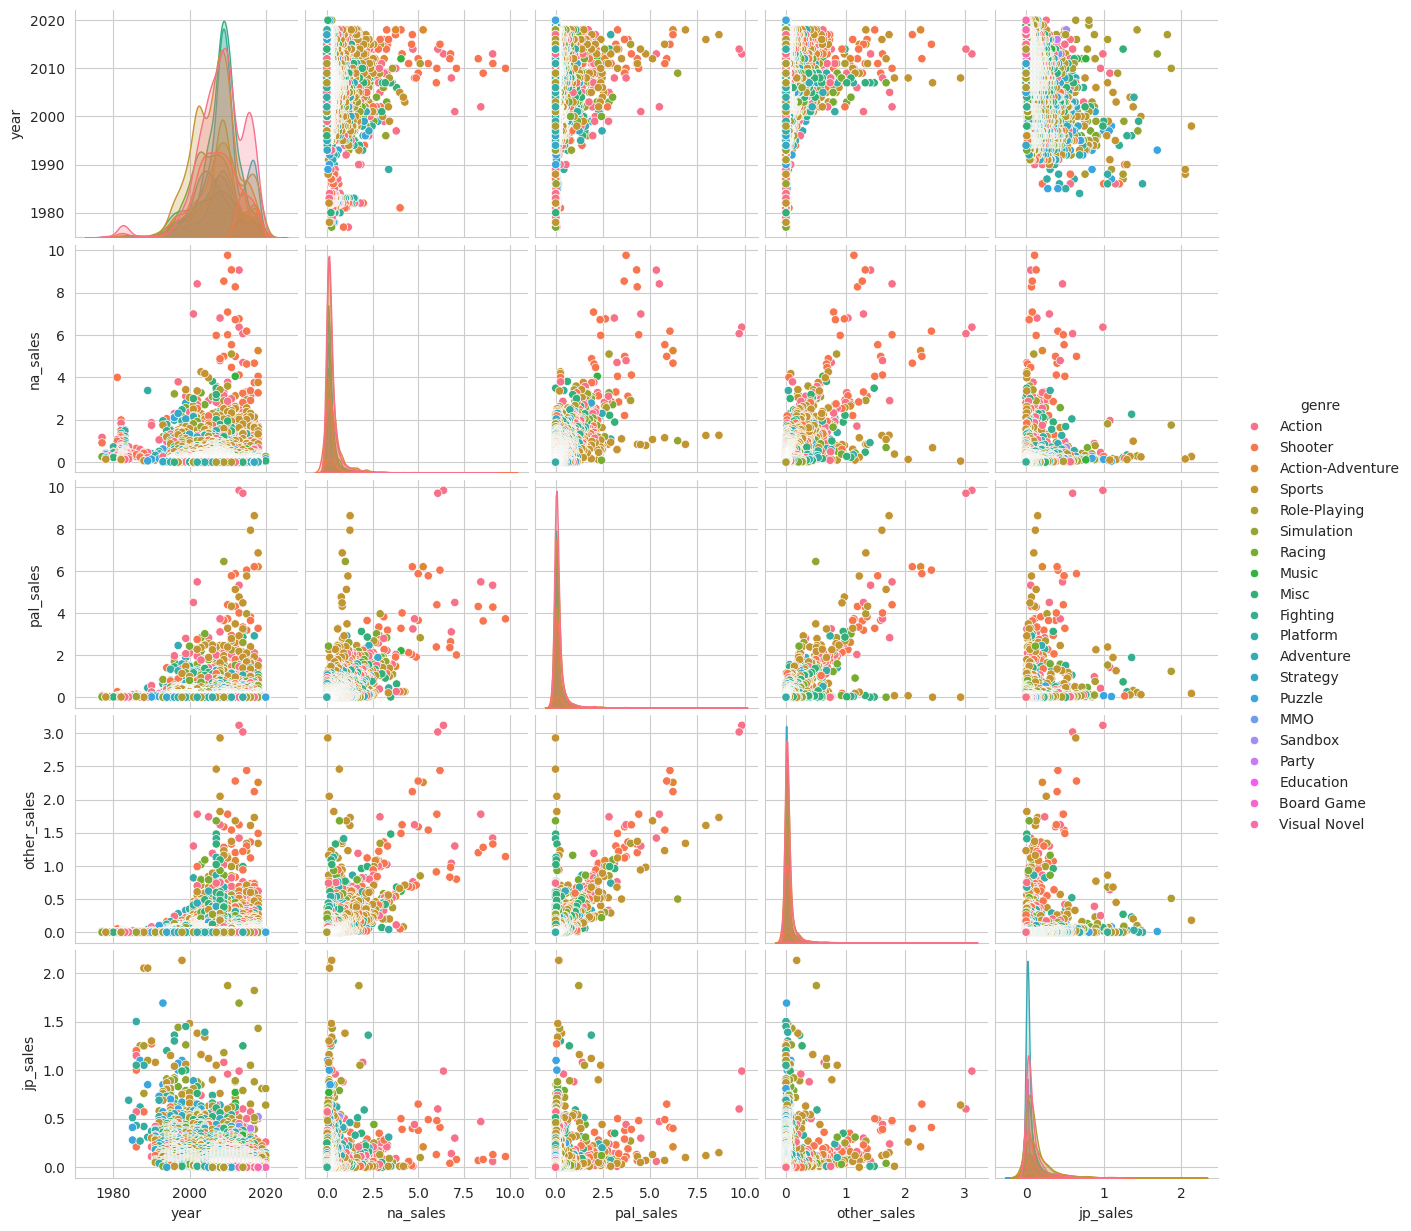

In [24]:
sns.pairplot(data_pair, hue='genre')

Transformación para determinar mejor la relación entre variables

In [25]:
data_pair_log = data_pair.copy()

In [26]:
data_pair_log = data_pair_log[data_pair_log.na_sales != 0]
data_pair_log = data_pair_log[data_pair_log.pal_sales != 0]
data_pair_log = data_pair_log[data_pair_log.jp_sales != 0]
data_pair_log = data_pair_log[data_pair_log.other_sales != 0]

In [27]:
data_pair_log['na_sales'] = np.log(data_pair_log['na_sales']);
data_pair_log['pal_sales'] = np.log(data_pair_log['pal_sales']);
data_pair_log['jp_sales'] = np.log(data_pair_log['jp_sales']);
data_pair_log['other_sales'] = np.log(data_pair_log['other_sales']);

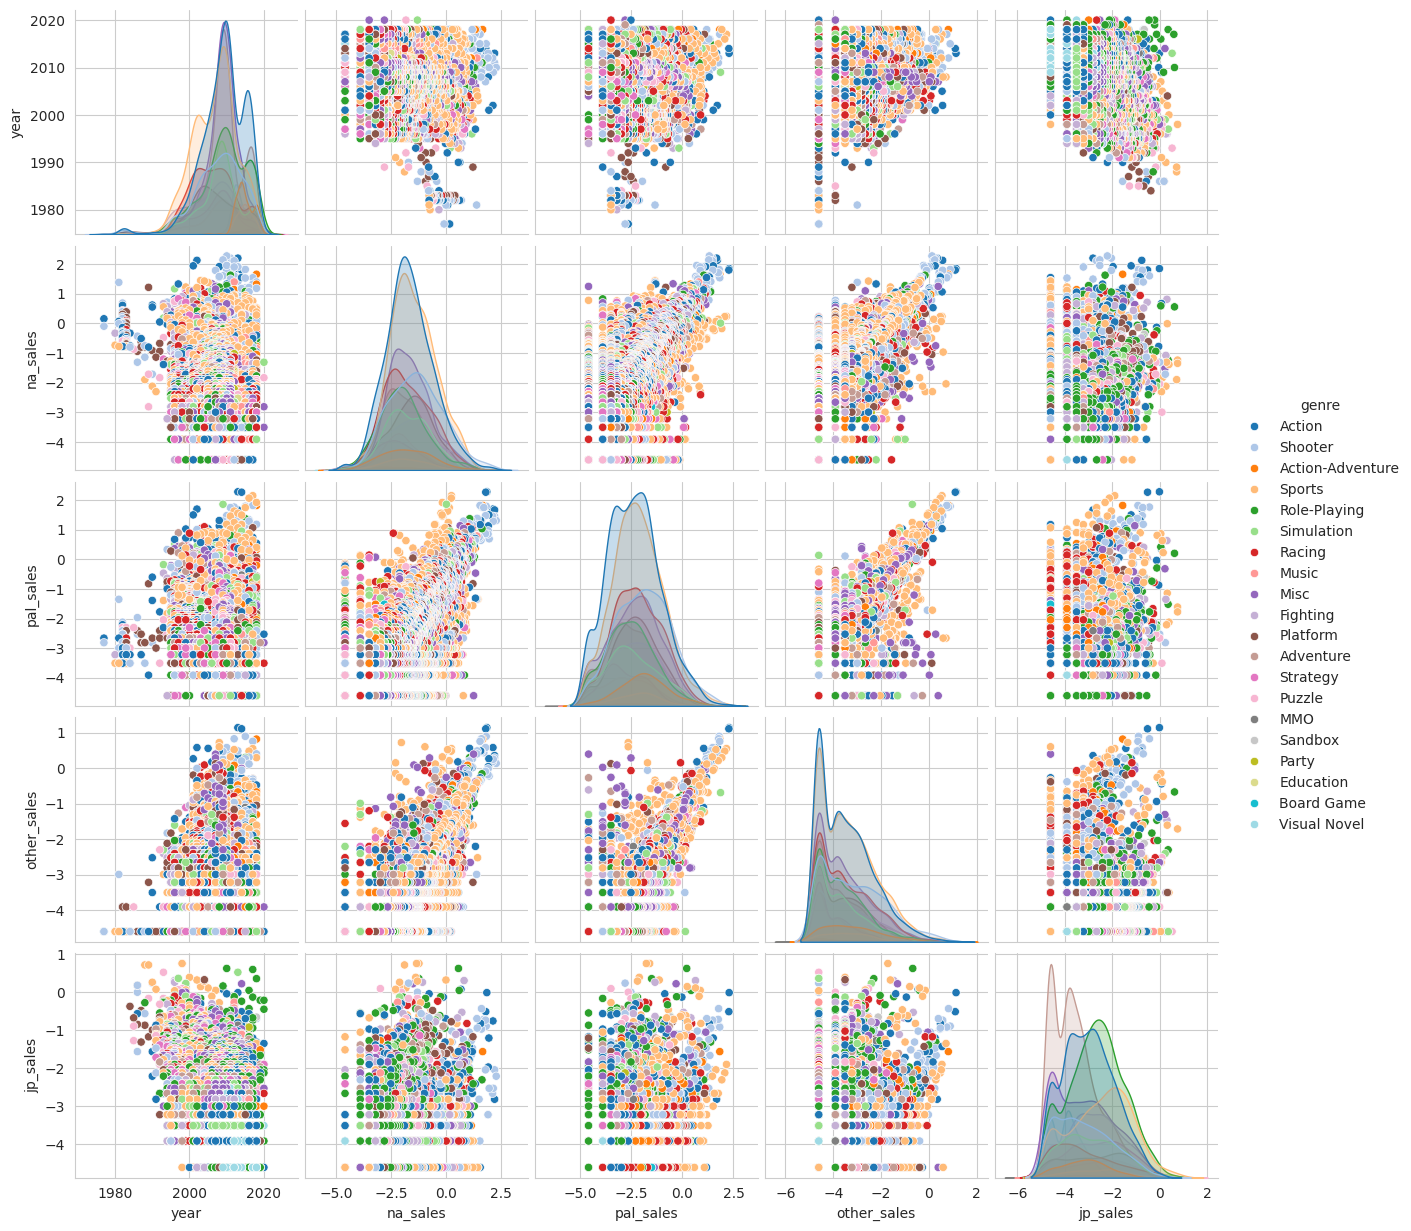

In [28]:
sns.pairplot(data_pair_log, hue='genre',  palette="tab20")

### 1. ¿Qué año tuvo las mayores ventas a nivel mundial?

In [29]:
data_highest_sales_y = df.groupby('year')['total_sales'].sum().sort_values(ascending=False);
data_highest_sales_y = data_highest_sales_y.reset_index();

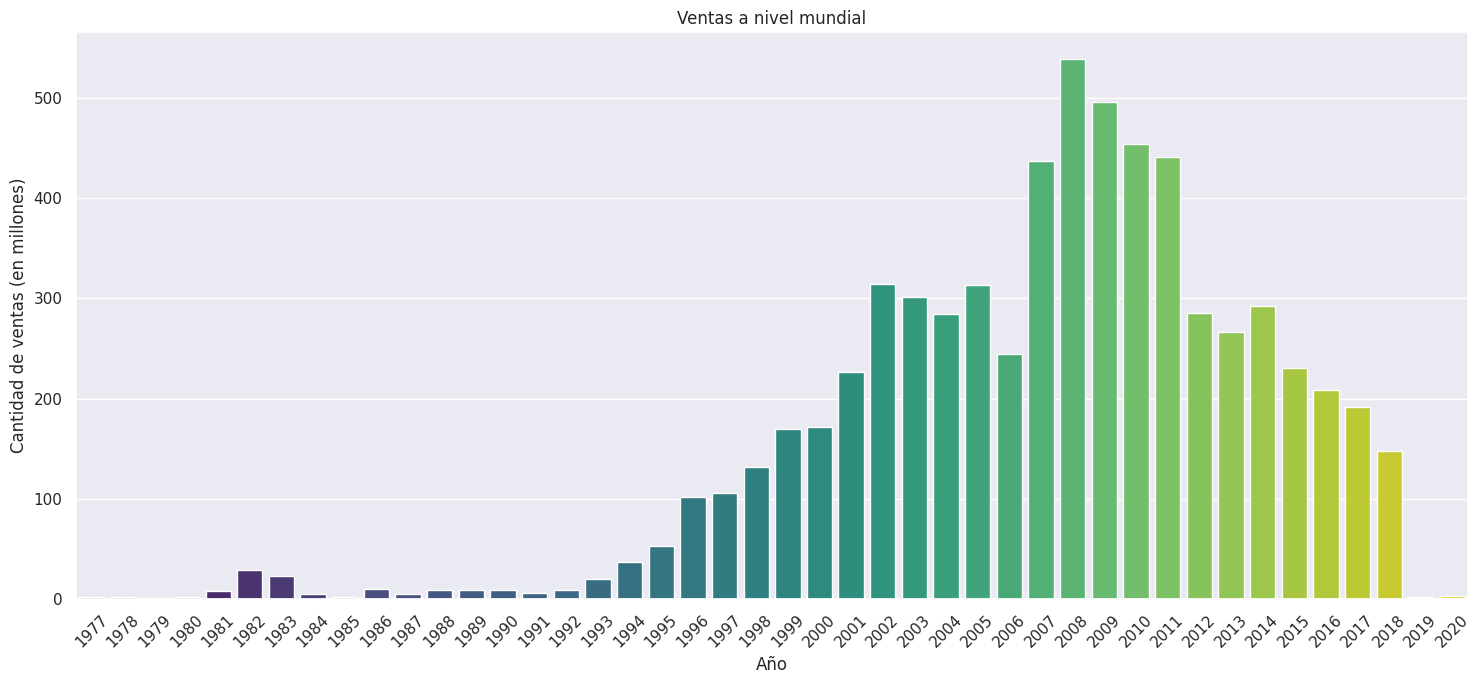

In [103]:
plt.figure(figsize=(15, 7))
sns.barplot(x='year', y='total_sales', data=data_highest_sales_y, palette='viridis', hue='year', legend=False)
plt.title('Ventas a nivel mundial')
plt.xlabel('Año')
plt.ylabel('Cantidad de ventas (en millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. ¿Qué género ha vendido más en un solo año?

In [47]:
# Agrupa por año, género y suma las filas de la columna total_sales
year_genre_s_df = df.groupby(['year', 'genre'])['total_sales'].sum().reset_index()

# Identifica las filas donde la suma de las ventas es el máximo para cada año
year_sale = year_genre_s_df.groupby('year')['total_sales'].transform(max) == year_genre_s_df['total_sales']

# Filtra para quedarse solo con el género con el mayor número de ventas por año
year_sale_max = year_genre_s_df[year_sale].reset_index(drop=True)

/tmp/ipykernel_10684/830444650.py:5: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  year_sale = year_genre_s_df.groupby('year')['total_sales'].transform(max) == year_genre_s_df['total_sales']


In [48]:
genre = year_sale_max['genre']

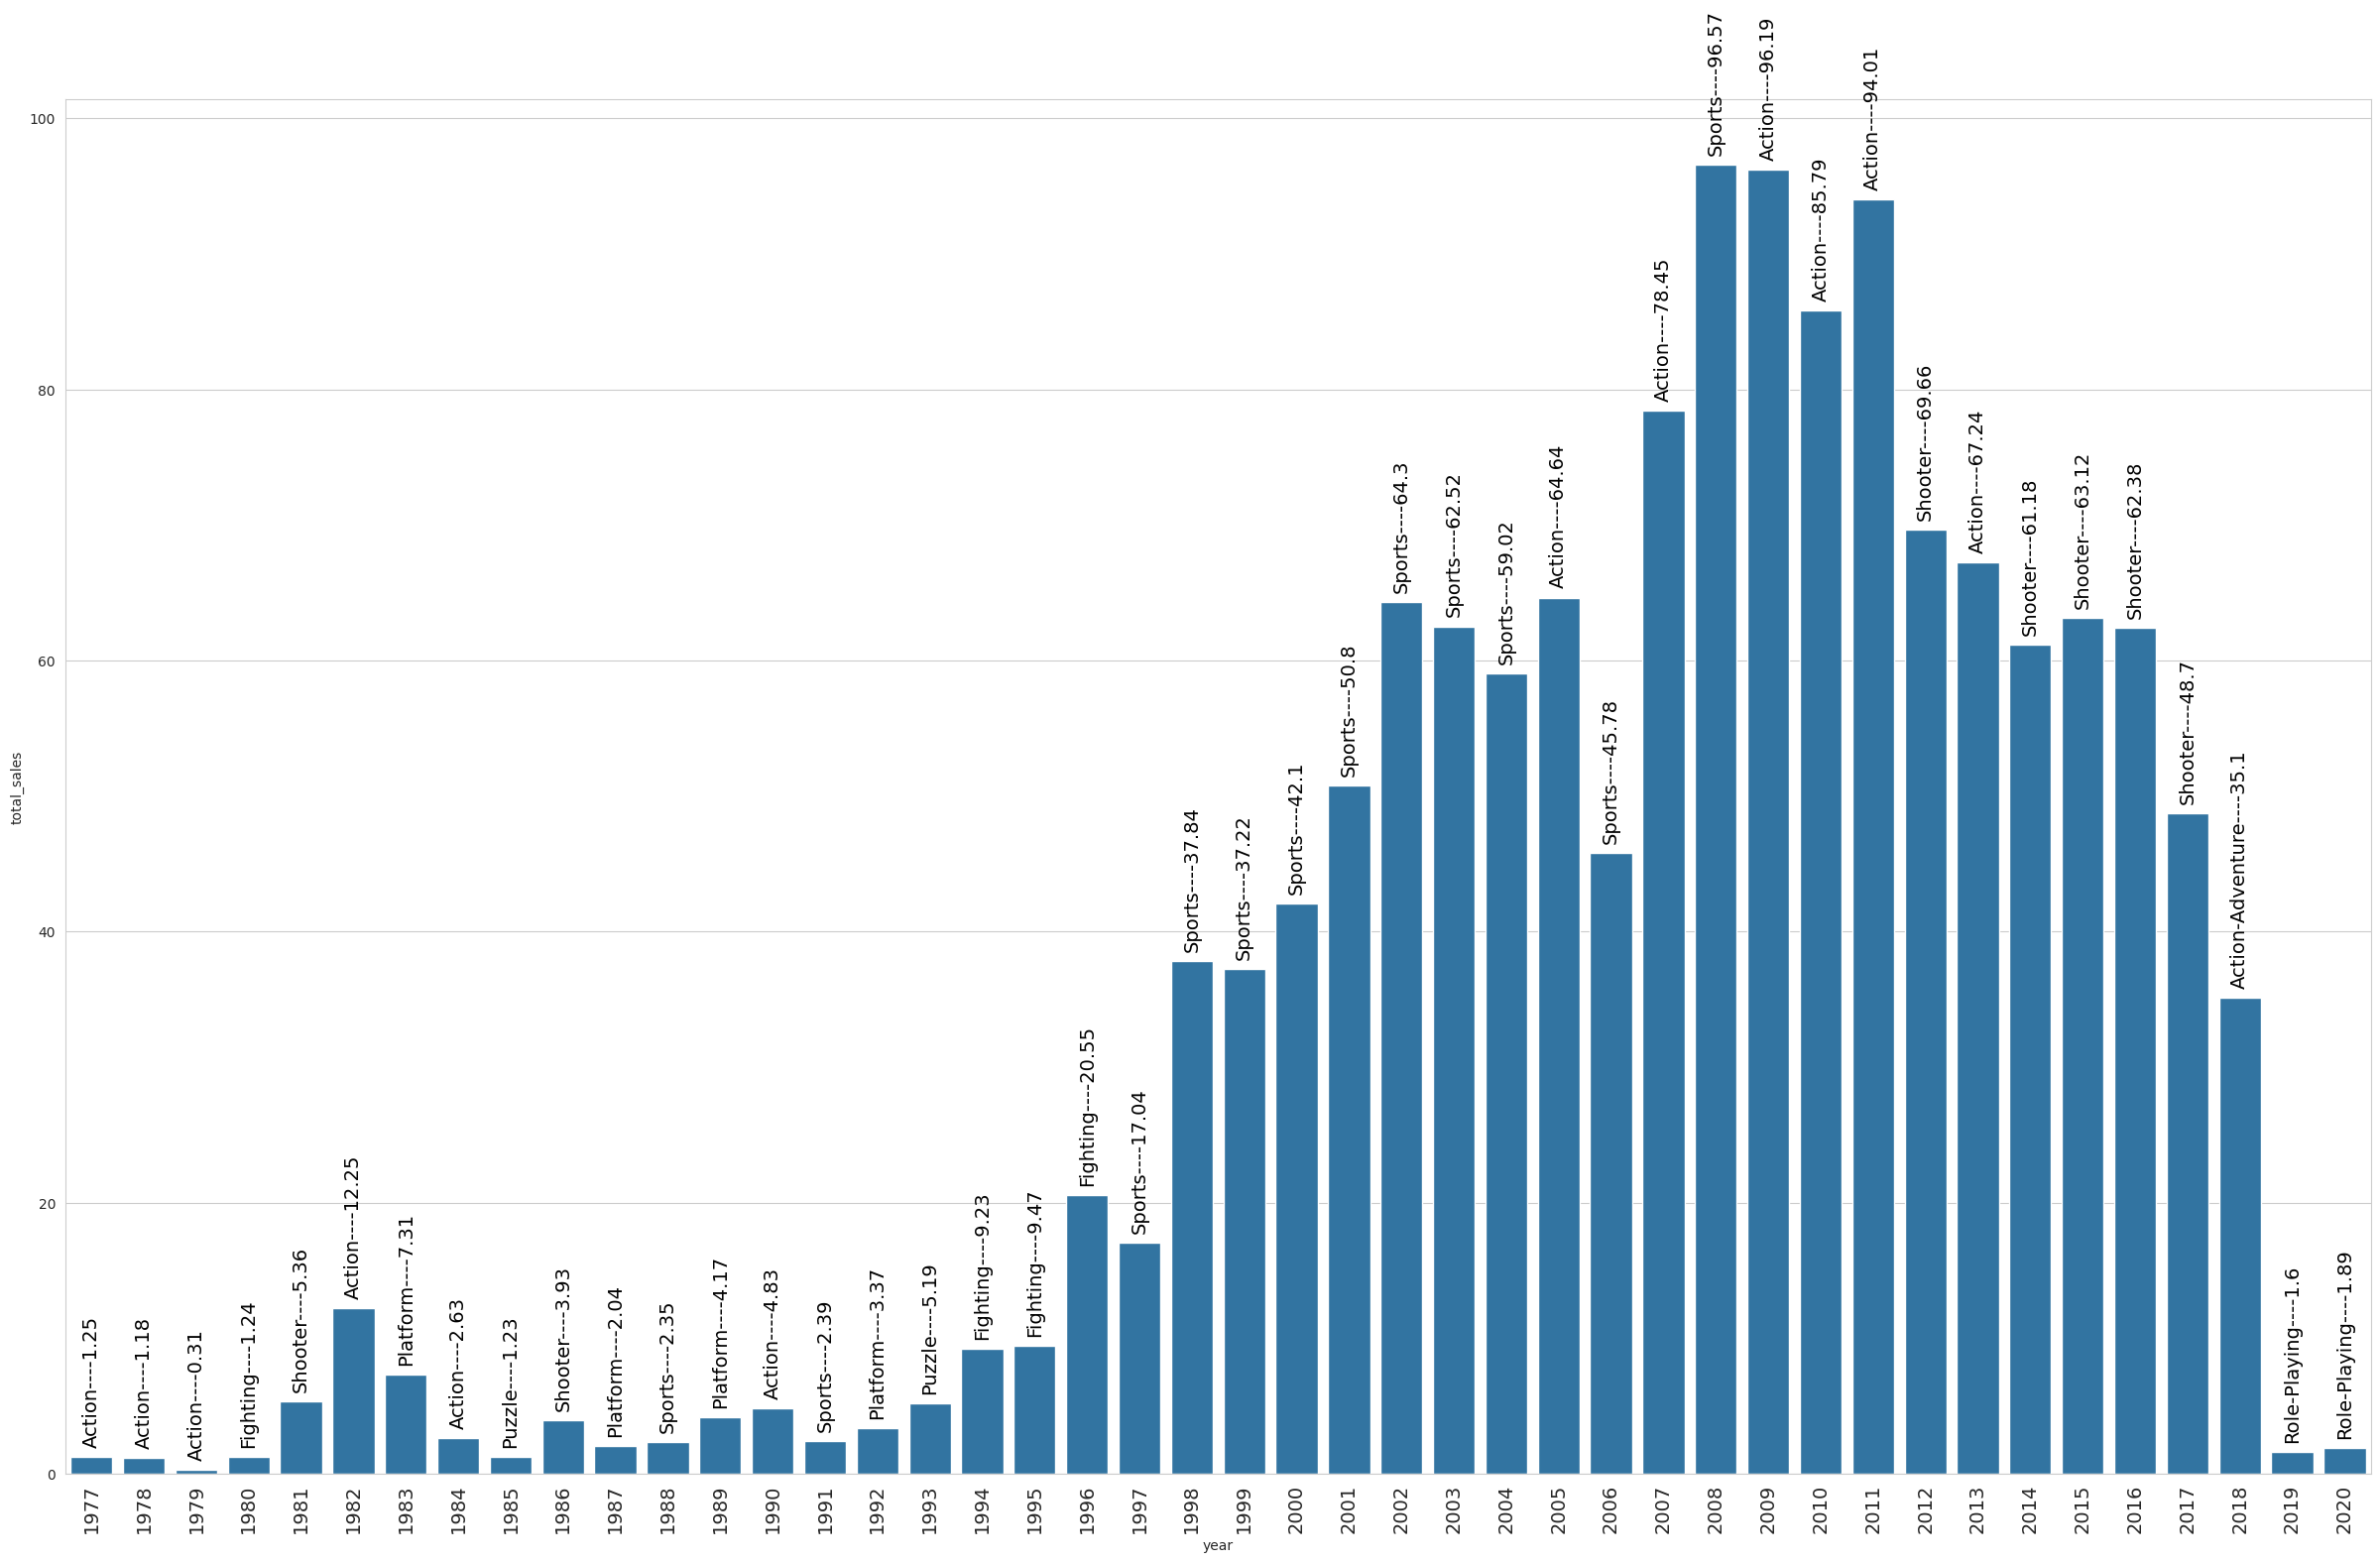

In [49]:
plt.figure(figsize=(30, 18))
g = sns.barplot(x='year', y='total_sales', data=year_sale_max)
index = 0
for value in year_sale_max['total_sales']:
    g.text(index, value + 1, str(genre[index] + '----' +str(round(value, 2))), color='#000', size=14, rotation= 90, ha="center")
    index += 1

plt.xticks(rotation=90, size=14)
plt.show()

### 3. ¿Cuáles son los 5 géneros con más ventas en todo el mundo?

In [54]:
top_5_genres = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False).head(5).reset_index()
top_5_genres

,genre,total_sales
0,Sports,1186.77
1,Action,1124.95
2,Shooter,995.47
3,Misc,557.55
4,Racing,523.51


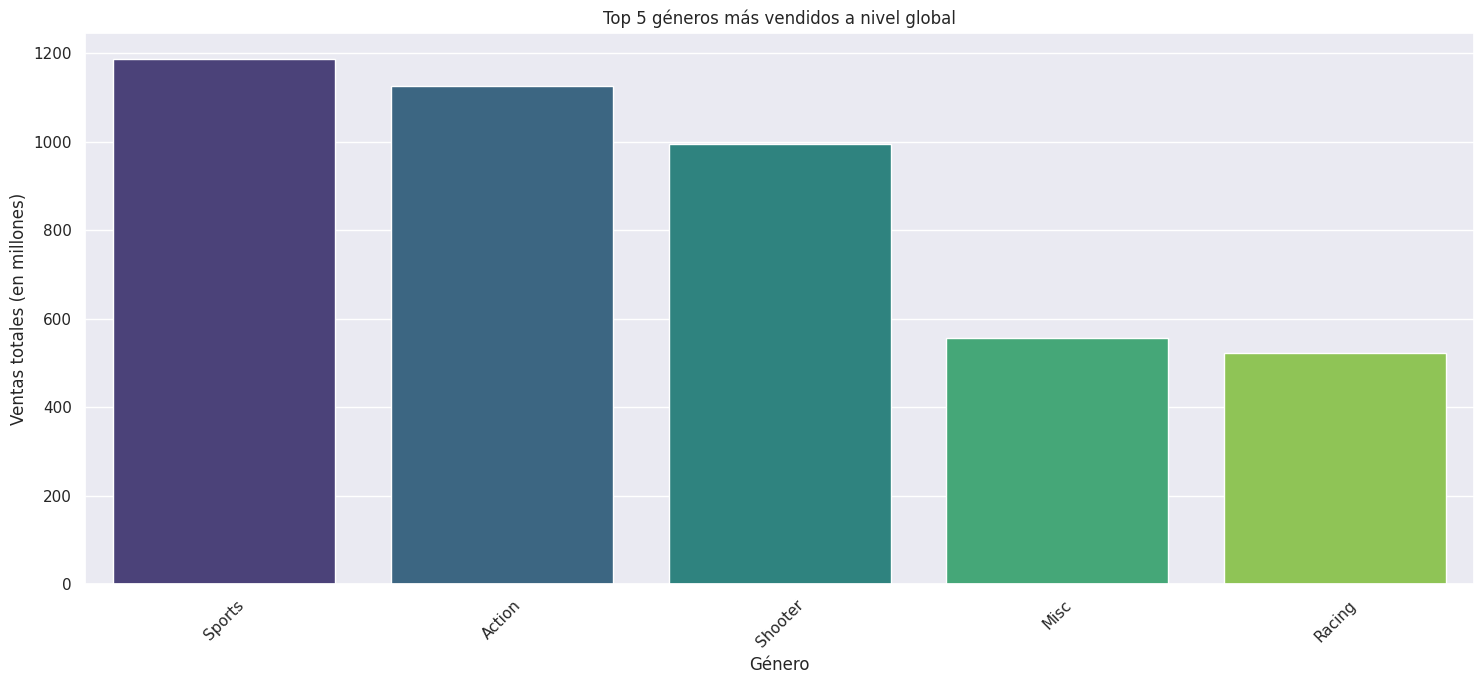

In [105]:
plt.figure(figsize=(15, 7))
sns.barplot(x='genre', y='total_sales', data=top_5_genres, palette='viridis', hue='genre', legend=False)
plt.title('Top 5 géneros más vendidos a nivel global')
plt.xlabel('Género')
plt.ylabel('Ventas totales (en millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4. ¿Qué plataforma acumula más ventas a nivel mundial?

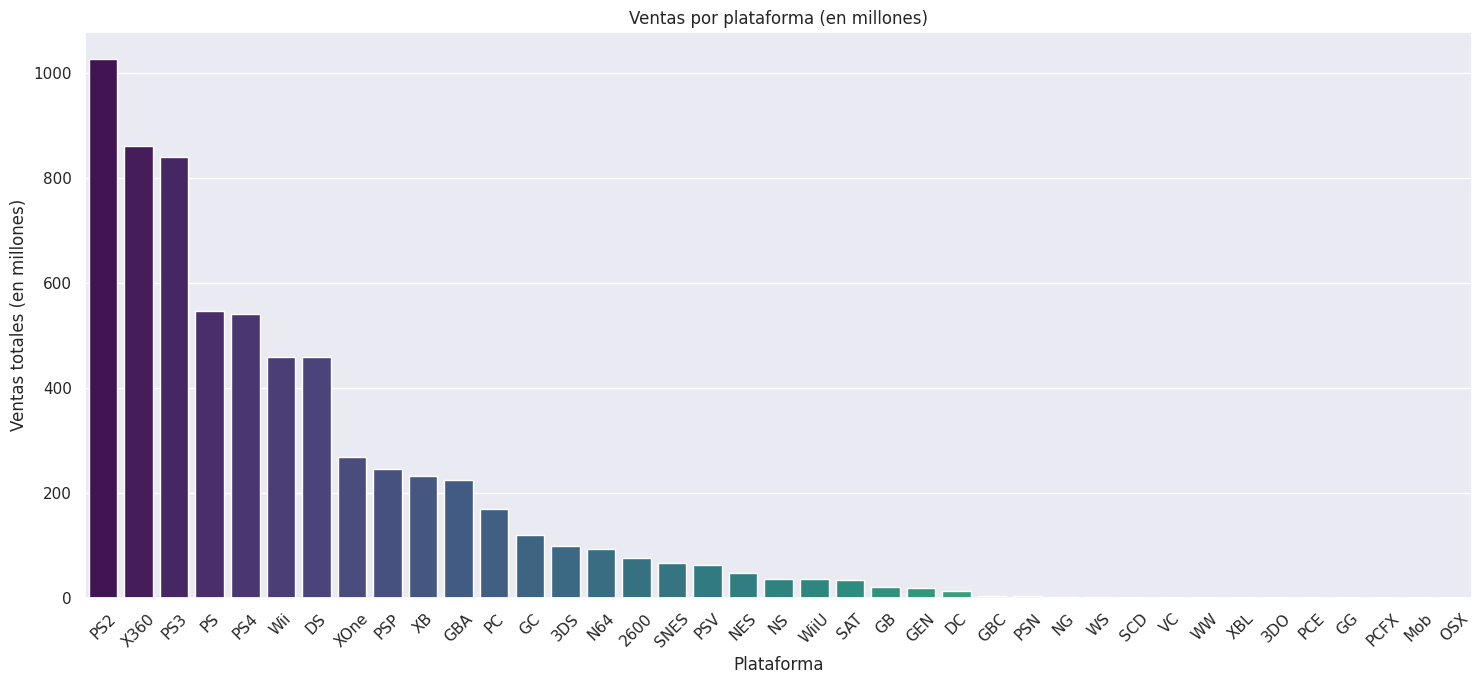

In [106]:
console_sales = df.groupby('console')['total_sales'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(15, 7))
sns.barplot(x='console', y='total_sales', data=console_sales, palette='viridis', hue='console', legend=False)
plt.title('Ventas por plataforma (en millones)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (en millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Top 10 juegos más vendidos en todo el mundo

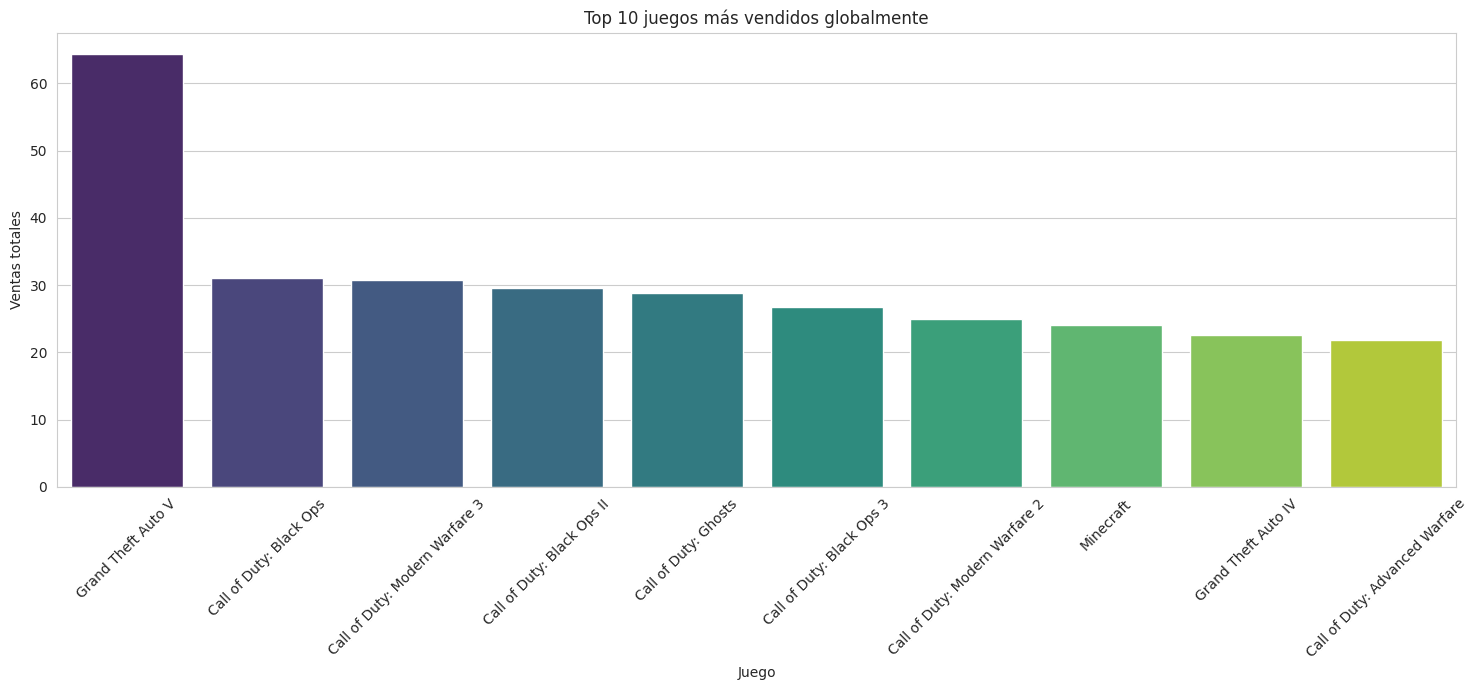

In [65]:
top_10_ms_games = df.groupby('title')['total_sales'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(15, 7))
sns.barplot(x='title', y='total_sales', data=top_10_ms_games, palette='viridis', hue='title', legend=False)
plt.title('Top 10 juegos más vendidos globalmente')
plt.xlabel('Juego')
plt.ylabel('Ventas totales (en millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6. Comparación de ventas por género y región.

In [69]:
comp_genre = df[['genre', 'na_sales', 'pal_sales', 'jp_sales', 'other_sales']]
comp_map = comp_genre.groupby('genre').sum()

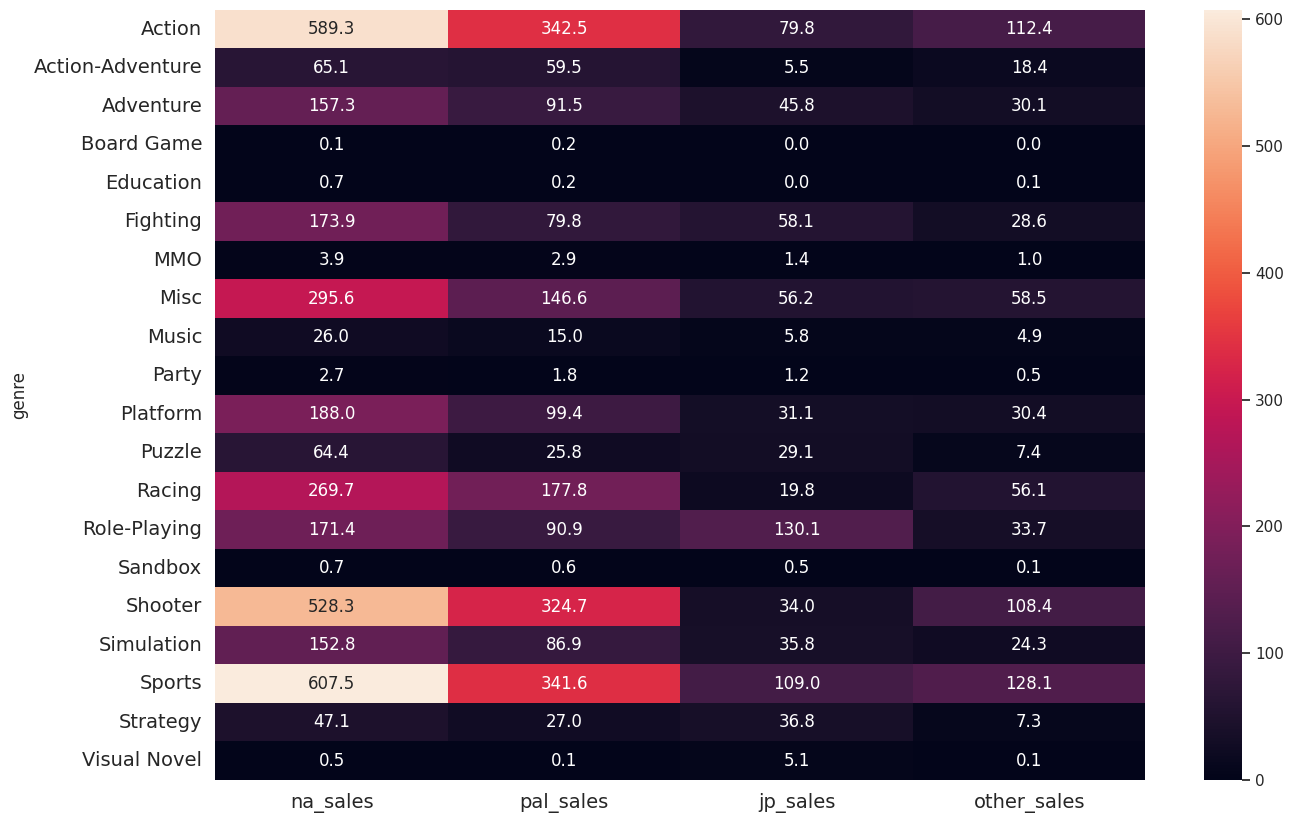

In [70]:
plt.figure(figsize=(15, 10))
sns.set(font_scale=1)
sns.heatmap(comp_map, annot=True, fmt = '.1f')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

### 7. Top 5 géneros más vendidos de las 5 plataformas con más ventas.

In [107]:
# Extrae las 5 plataformas con más ventas reutilizando una variable anterior
top_5_bs_platforms = console_sales.head(5)['console'].tolist()
df_best_s_platforms = df[df['console'].isin(top_5_bs_platforms)]

# Calcula los 5 géneros con más ventas
top_5_genres_sales = df_best_s_platforms.groupby('genre')['total_sales'].sum().nlargest(5).index

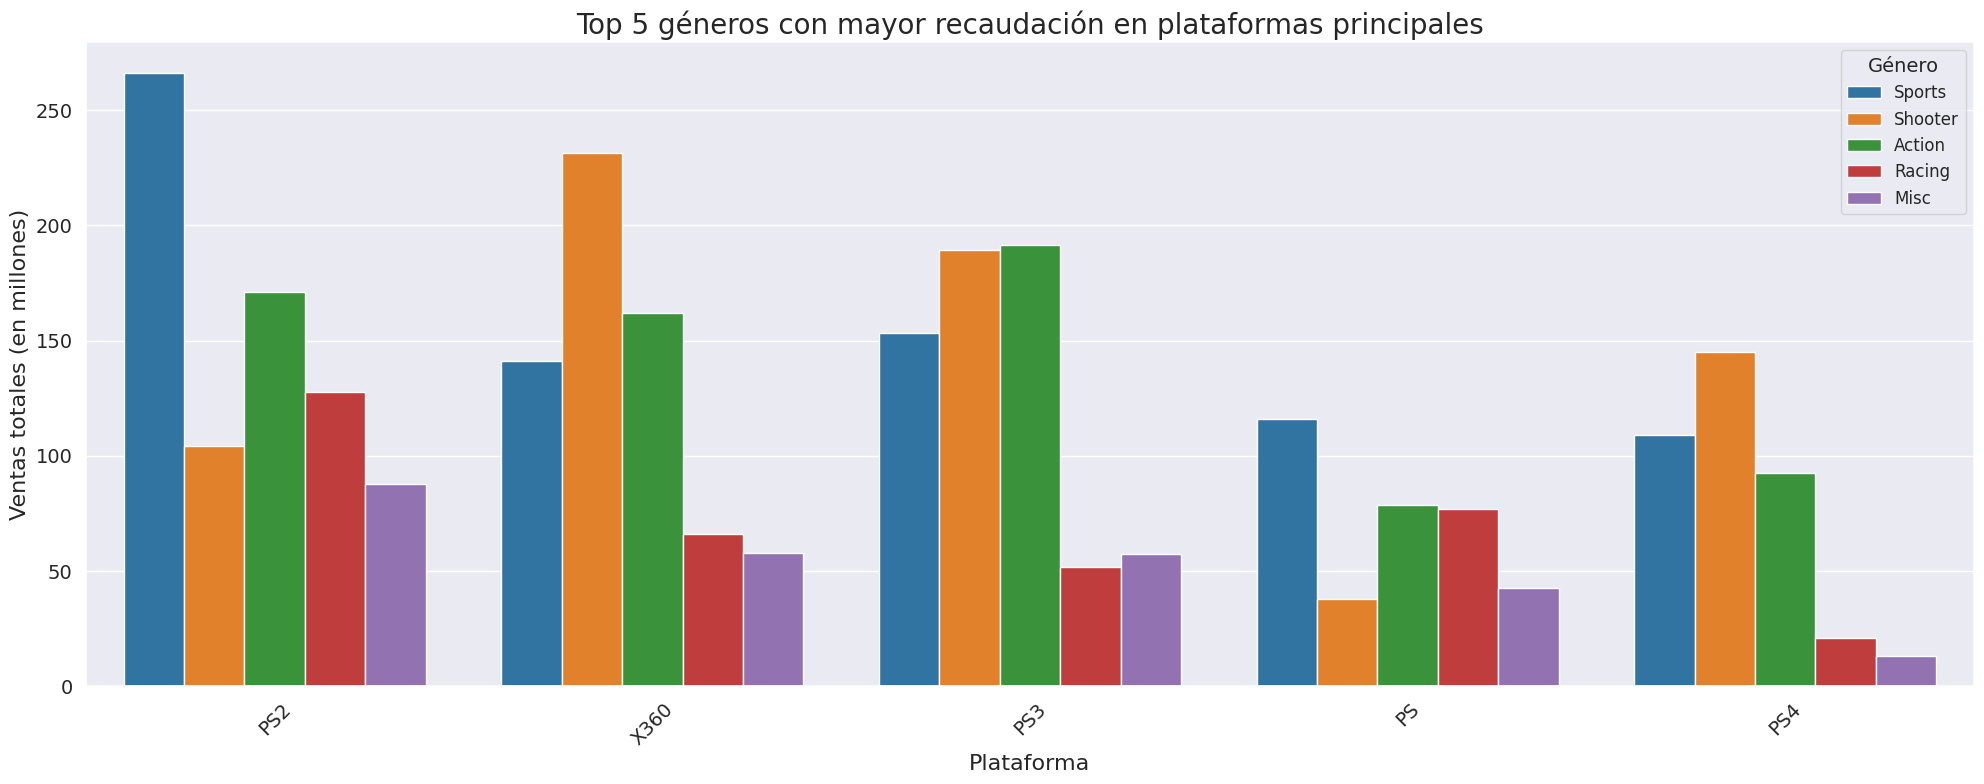

In [108]:
plt.figure(figsize=(20, 8))
sns.barplot(
    x="console",
    y="total_sales",
    data=df_best_s_platforms,
    hue='genre',
    order=top_5_bs_platforms,
    hue_order=top_5_genres_sales,
    estimator='sum',
    errorbar=None,
    palette='tab10'
)

plt.title('Top 5 géneros con mayor recaudación en plataformas principales', fontsize=20)
plt.xlabel('Plataforma', fontsize=16)
plt.ylabel('Ventas totales (en millones)', fontsize=16)
plt.xticks(size=14, rotation=45)
plt.yticks(size=14)
plt.legend(title='Género', title_fontsize='14', fontsize='12', loc='upper right')
plt.tight_layout()
plt.show()

### 8. Ventas globales y por área según editor.

In [123]:
comp_publisher = df[['publisher', 'na_sales', 'pal_sales', 'jp_sales', 'other_sales', 'total_sales']]
comp_publisher.head()

,publisher,na_sales,pal_sales,jp_sales,other_sales,total_sales
0,Rockstar Games,6.37,9.85,0.99,3.12,20.32
1,Rockstar Games,6.06,9.71,0.60,3.02,19.39
2,Rockstar Games,8.41,5.49,0.47,1.78,16.15
3,Rockstar Games,9.06,5.33,0.06,1.42,15.86
4,Activision,6.18,6.05,0.41,2.44,15.09


In [124]:
comp_publisher = comp_publisher.groupby('publisher').sum().reset_index().sort_values(by=['total_sales'], ascending=False)
comp_publisher = comp_publisher.head(10) #Se limita a 10 para mayor legibilidad

In [125]:
comp_publisher = pd.melt(comp_publisher, id_vars=['publisher'], value_vars=['na_sales', 'pal_sales', 'jp_sales', 'other_sales'], var_name='sale_region', value_name='sales')
comp_publisher

,publisher,sale_region,sales
0,Activision,na_sales,423.73
1,Electronic Arts,na_sales,321.88
2,EA Sports,na_sales,267.19
3,Ubisoft,na_sales,239.30
4,THQ,na_sales,199.22
5,Sony Computer Entertainment,na_sales,134.49
6,Rockstar Games,na_sales,114.69
7,Konami,na_sales,66.18
8,Sega,na_sales,84.28
9,Nintendo,na_sales,53.48


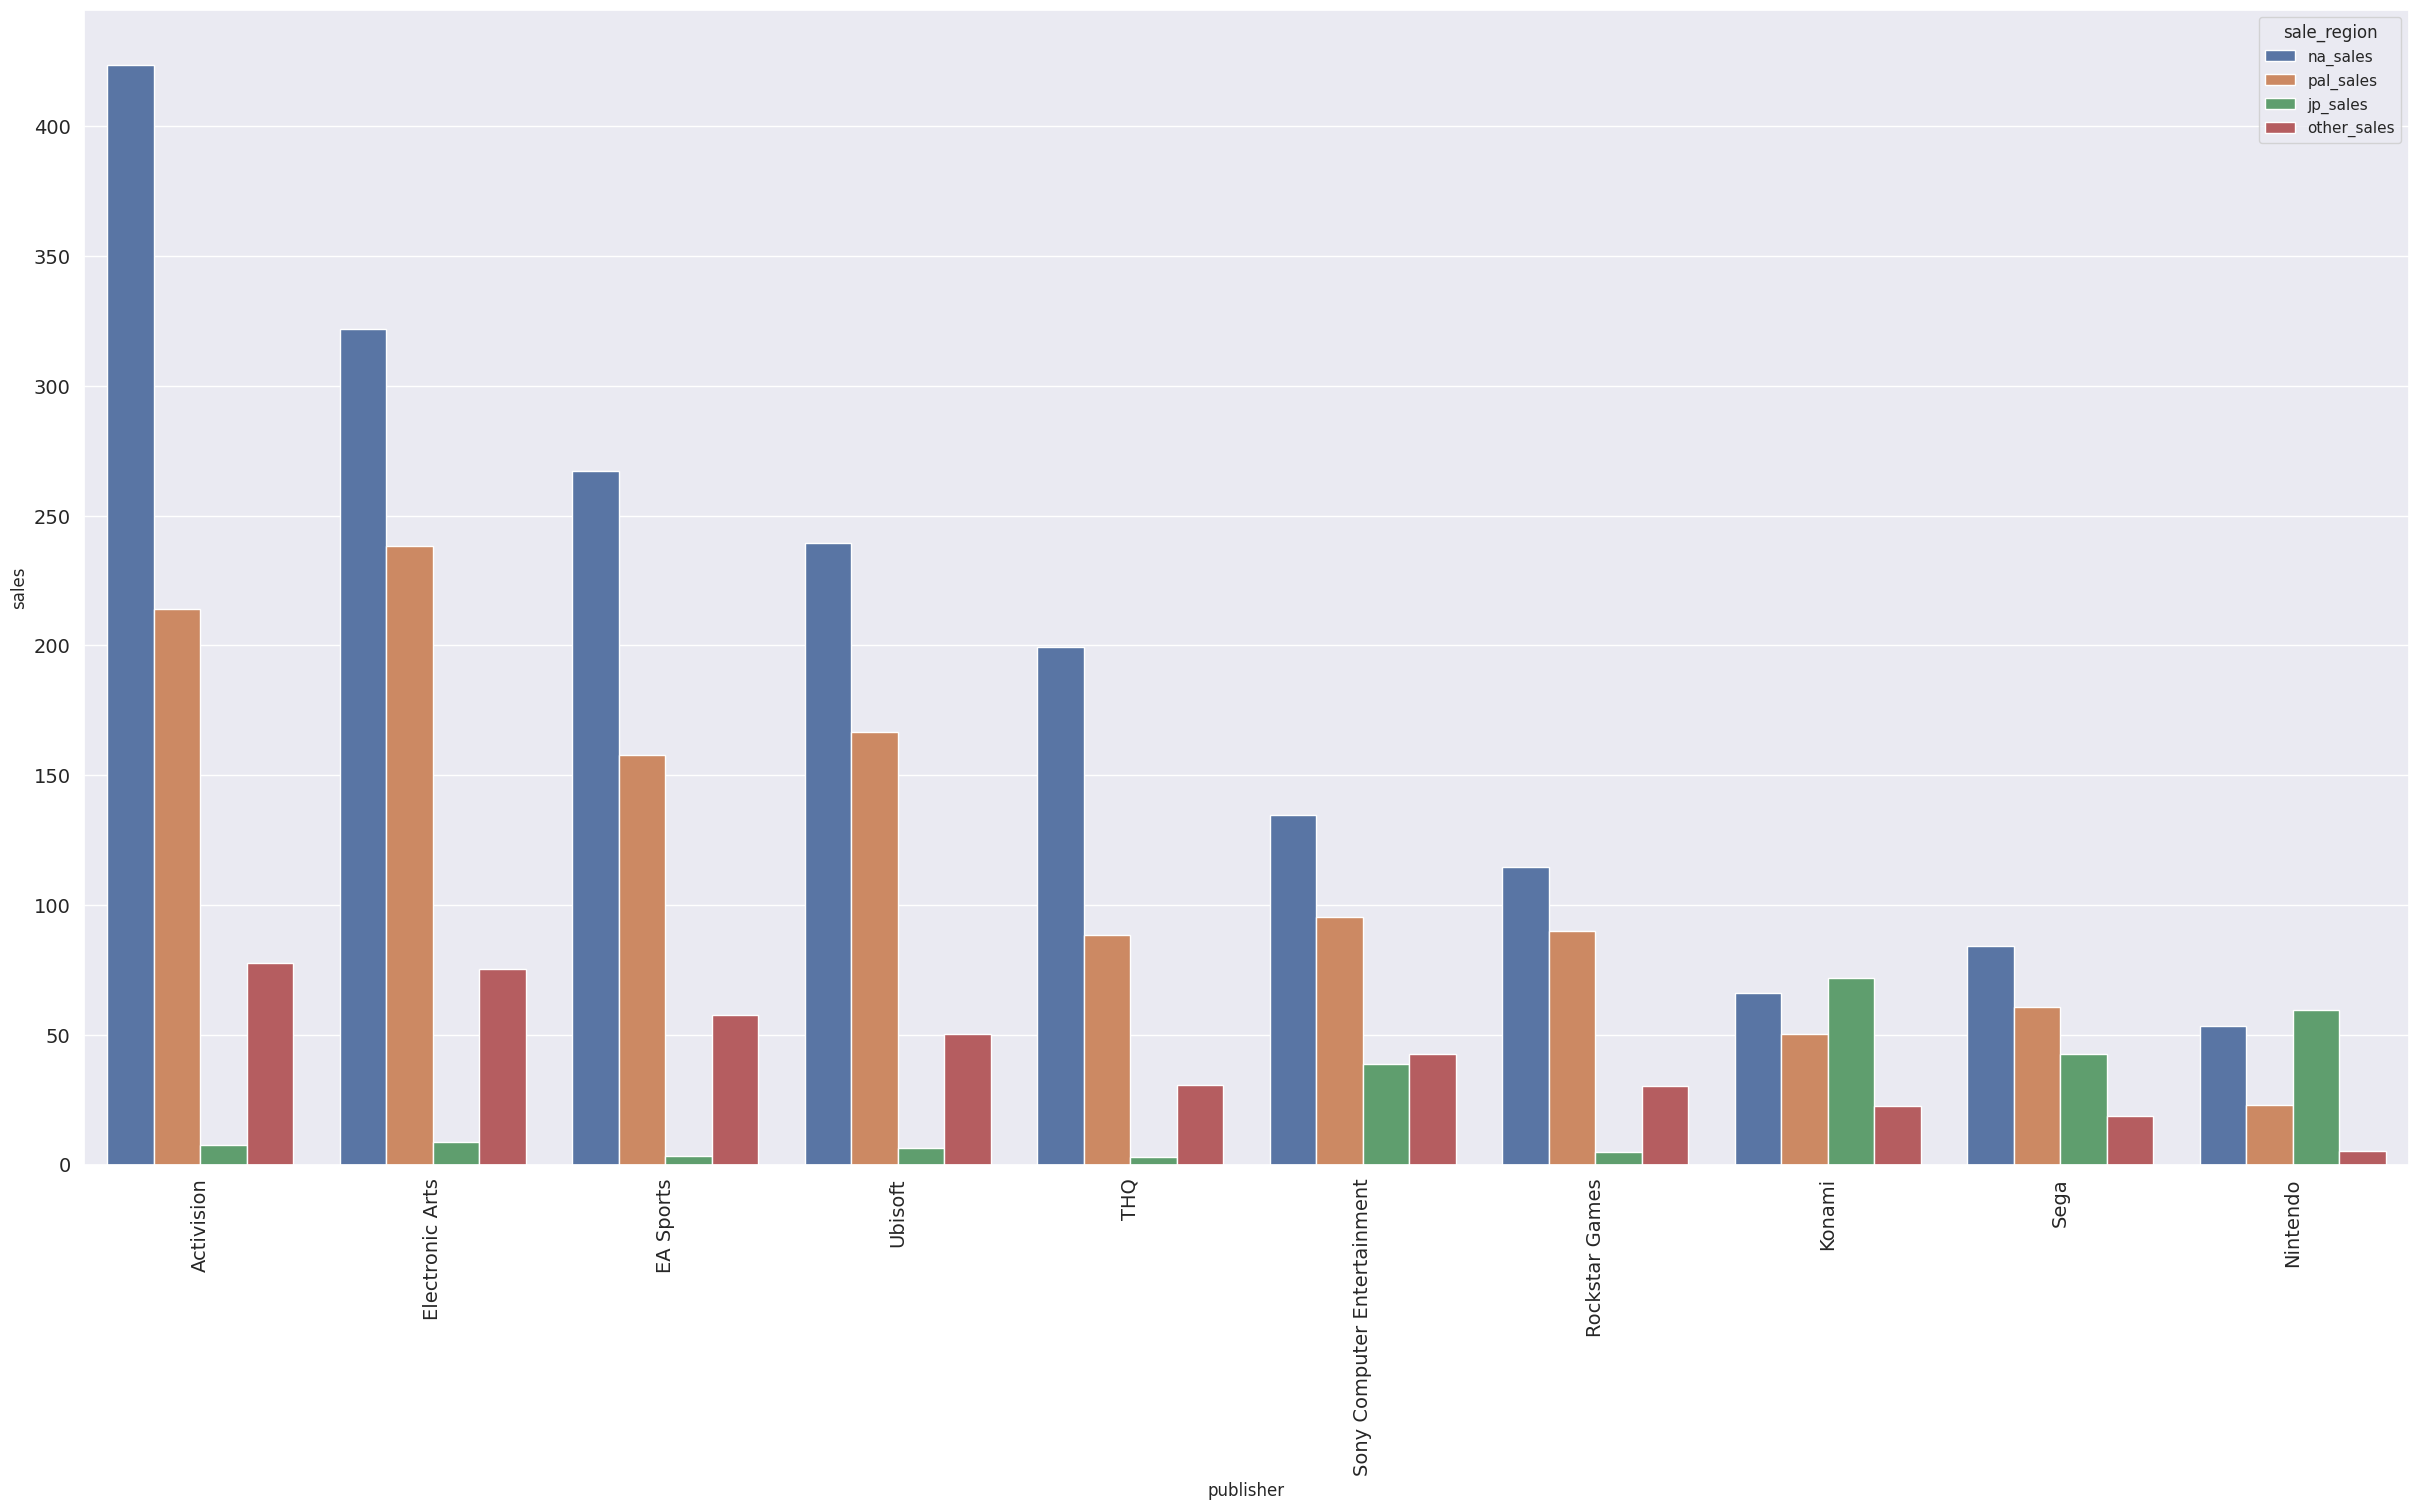

In [127]:
plt.figure(figsize=(30, 15))
sns.barplot(x='publisher', y='sales', hue='sale_region', data=comp_publisher)
plt.xticks(fontsize=14, rotation=90)
plt.yticks(fontsize=14)
plt.show()

### 9. Ventas totales por región.

In [129]:
sales_region_df = df[['na_sales', 'pal_sales', 'jp_sales', 'other_sales']]
sales_region_df = sales_region_df.sum().reset_index()
sales_region_df = sales_region_df.rename(columns={"index": "region", 0: "sale"})
sales_region_df

,region,sale
0,na_sales,3344.76
1,pal_sales,1914.64
2,jp_sales,684.99
3,other_sales,650.51


<Axes: xlabel='region', ylabel='sale'>

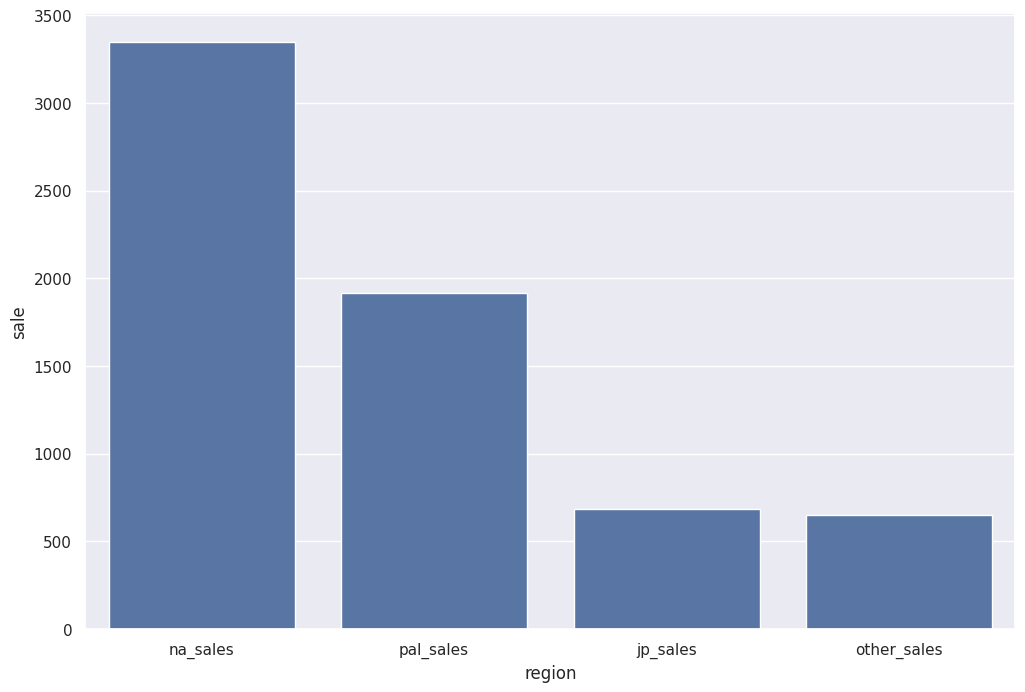

In [131]:
plt.figure(figsize=(12, 8))
sns.barplot(x='region', y='sale', data = sales_region_df)

In [132]:
labels = sales_region_df['region']
sizes = sales_region_df['sale']

([<matplotlib.patches.Wedge at 0x7c1a66a5ce30>,
 [Text(-1.0997206558266546, -0.02478868992489859, 'na_sales'),
  Text(0.8993063607861776, -0.6334414491091672, 'pal_sales'),
  Text(0.892234830142039, 0.6433638223287093, 'jp_sales'),
  Text(0.33544020327960816, 1.0476067344303088, 'other_sales')],
 [Text(-0.5998476304509025, -0.01352110359539923, '50.7%'),
  Text(0.4905307422470059, -0.3455135176959093, '29.0%'),
  Text(0.48667354371383936, 0.35092572127020505, '10.4%'),
  Text(0.182967383607059, 0.5714218551438047, '9.9%')])

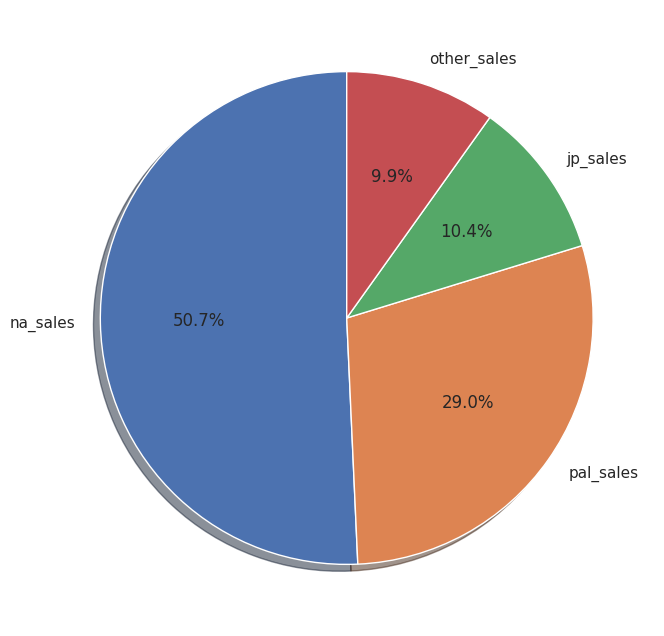

In [133]:
plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)